# Image Processing Techniques with Local PNG Images

This notebook applies various geometric and classical image processing techniques to PNG images stored locally in the Lab 2 folder.

## Techniques covered:
- Geometric transformations (rotation, scaling, translation)
- Edge detection (Canny, Sobel, Laplacian)
- Image filtering (blur, sharpen)
- Morphological operations (erosion, dilation, opening, closing)
- Thresholding techniques
- Histogram equalization
- Contour detection

## Step 1: Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['image.cmap'] = 'gray'

## Step 2: Set Up Image Directory and Load Images

In [2]:
# Get the current working directory
LAB_DIR = Path.cwd()
print(f"Lab directory: {LAB_DIR}")

# Find all PNG images in the directory
image_files = sorted(LAB_DIR.glob("*.png"))
print(f"\nFound {len(image_files)} PNG images:")
for img_file in image_files:
    print(f"  - {img_file.name}")

Lab directory: /Users/muhammadjonparpiyev/Library/Mobile Documents/com~apple~CloudDocs/Documents/DIP/Week 13/Lab 2

Found 6 PNG images:
  - front_15.png
  - front_2.png
  - front_3.png
  - top_15.png
  - top_2.png
  - top_3.png


## Step 3: Load and Display Sample Image

Loaded image: front_15.png
Image shape: (1080, 1920, 3)
Data type: uint8


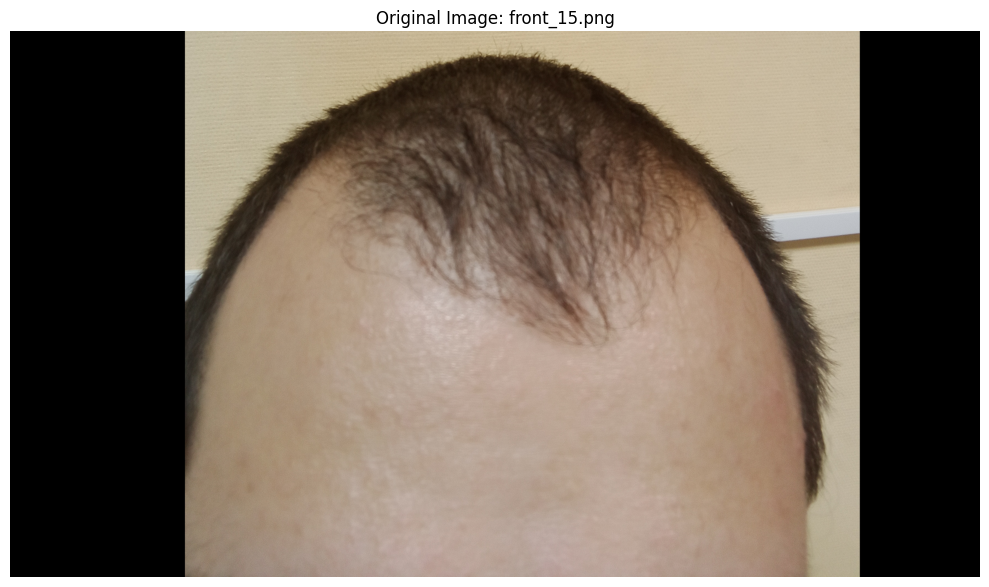

In [3]:
# Load the first image
if len(image_files) > 0:
    sample_image_path = image_files[0]
    img = cv2.imread(str(sample_image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    print(f"Loaded image: {sample_image_path.name}")
    print(f"Image shape: {img.shape}")
    print(f"Data type: {img.dtype}")
    
    # Display original image
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(f"Original Image: {sample_image_path.name}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No PNG images found in the directory!")

## Step 4: Geometric Transformations

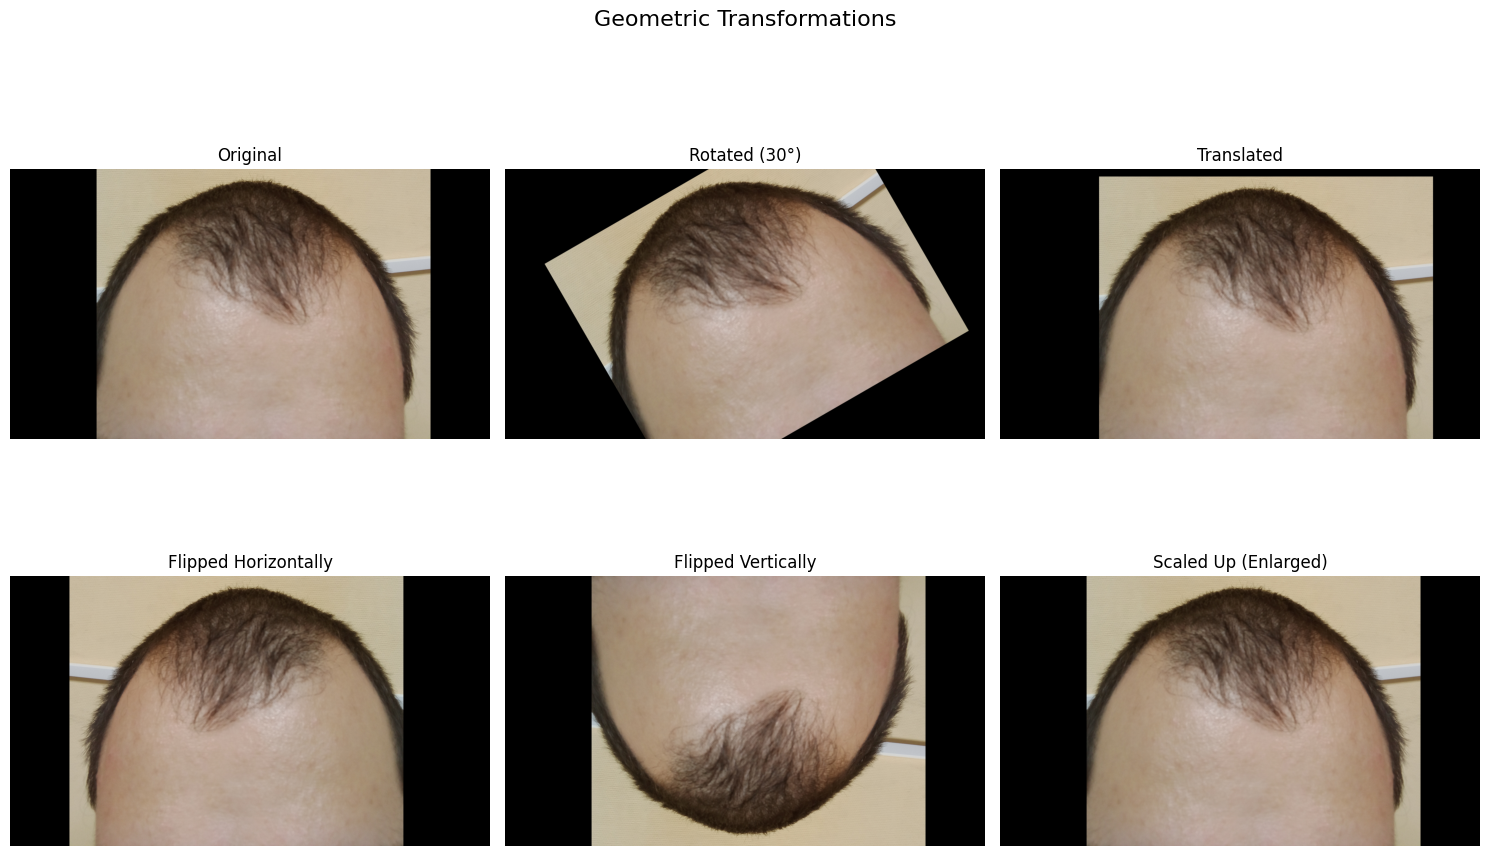

In [4]:
# Geometric transformations

# 1. Rotation
height, width = img_gray.shape
center = (width // 2, height // 2)
rotation_matrix = cv2.getRotationMatrix2D(center, angle=30, scale=1.0)
rotated = cv2.warpAffine(img_rgb, rotation_matrix, (width, height))

# 2. Scaling (Resize)
scaled = cv2.resize(img_rgb, (width // 2, height // 2))
scaled_enlarged = cv2.resize(img_rgb, (width + 100, height + 100))

# 3. Translation
translation_matrix = np.float32([[1, 0, 50], [0, 1, 30]])
translated = cv2.warpAffine(img_rgb, translation_matrix, (width, height))

# 4. Flipping
flipped_horizontal = cv2.flip(img_rgb, 1)  # Flip horizontally
flipped_vertical = cv2.flip(img_rgb, 0)    # Flip vertically

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(rotated)
axes[0, 1].set_title('Rotated (30°)')
axes[0, 1].axis('off')

axes[0, 2].imshow(translated)
axes[0, 2].set_title('Translated')
axes[0, 2].axis('off')

axes[1, 0].imshow(flipped_horizontal)
axes[1, 0].set_title('Flipped Horizontally')
axes[1, 0].axis('off')

axes[1, 1].imshow(flipped_vertical)
axes[1, 1].set_title('Flipped Vertically')
axes[1, 1].axis('off')

axes[1, 2].imshow(cv2.resize(scaled_enlarged, (width, height)))
axes[1, 2].set_title('Scaled Up (Enlarged)')
axes[1, 2].axis('off')

plt.suptitle('Geometric Transformations', fontsize=16)
plt.tight_layout()
plt.show()

## Step 5: Edge Detection

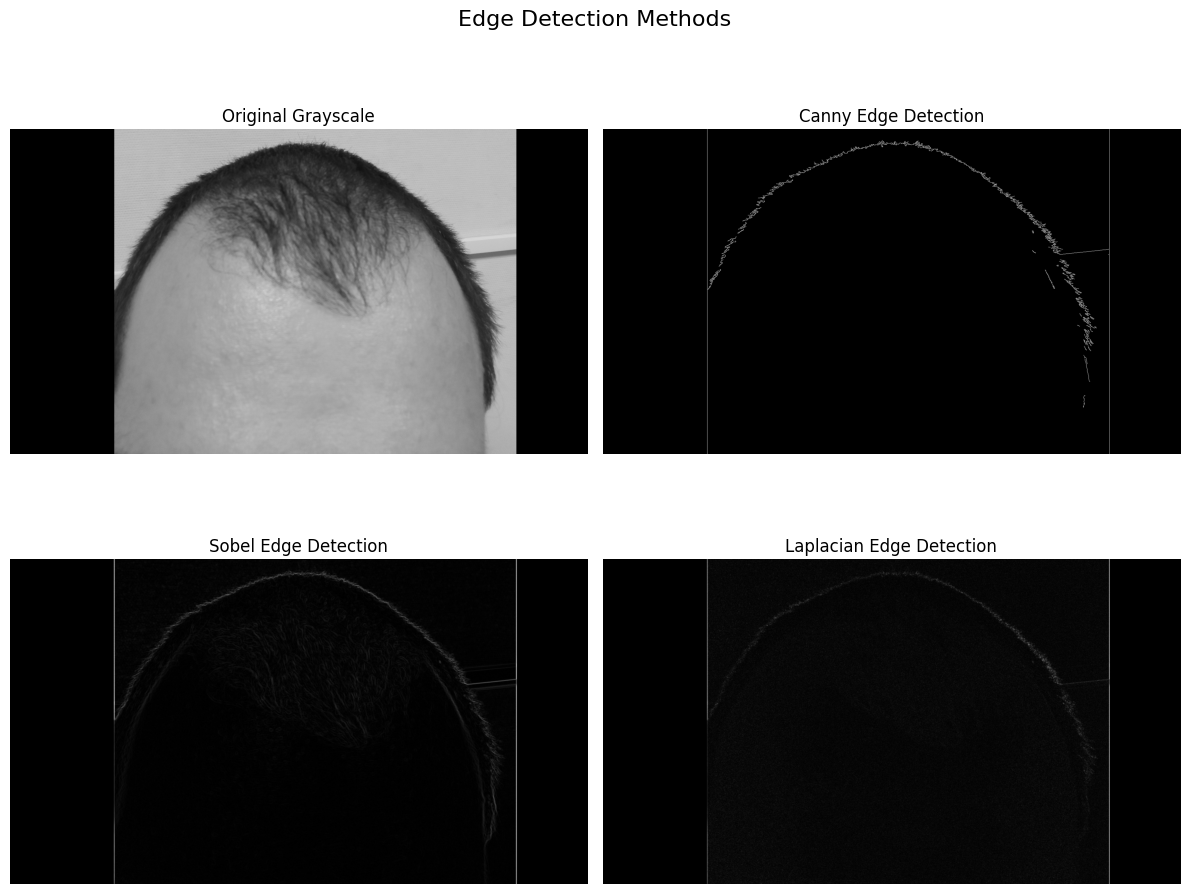

In [5]:
# Edge detection techniques

# 1. Canny Edge Detection
edges_canny = cv2.Canny(img_gray, threshold1=100, threshold2=200)

# 2. Sobel Edge Detection
sobel_x = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5)
sobel = np.sqrt(sobel_x**2 + sobel_y**2)
sobel = np.uint8(255 * sobel / np.max(sobel))

# 3. Laplacian Edge Detection
laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
laplacian = np.uint8(np.absolute(laplacian))

# Display results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale')
axes[0, 0].axis('off')

axes[0, 1].imshow(edges_canny, cmap='gray')
axes[0, 1].set_title('Canny Edge Detection')
axes[0, 1].axis('off')

axes[1, 0].imshow(sobel, cmap='gray')
axes[1, 0].set_title('Sobel Edge Detection')
axes[1, 0].axis('off')

axes[1, 1].imshow(laplacian, cmap='gray')
axes[1, 1].set_title('Laplacian Edge Detection')
axes[1, 1].axis('off')

plt.suptitle('Edge Detection Methods', fontsize=16)
plt.tight_layout()
plt.show()

## Step 6: Image Filtering and Smoothing

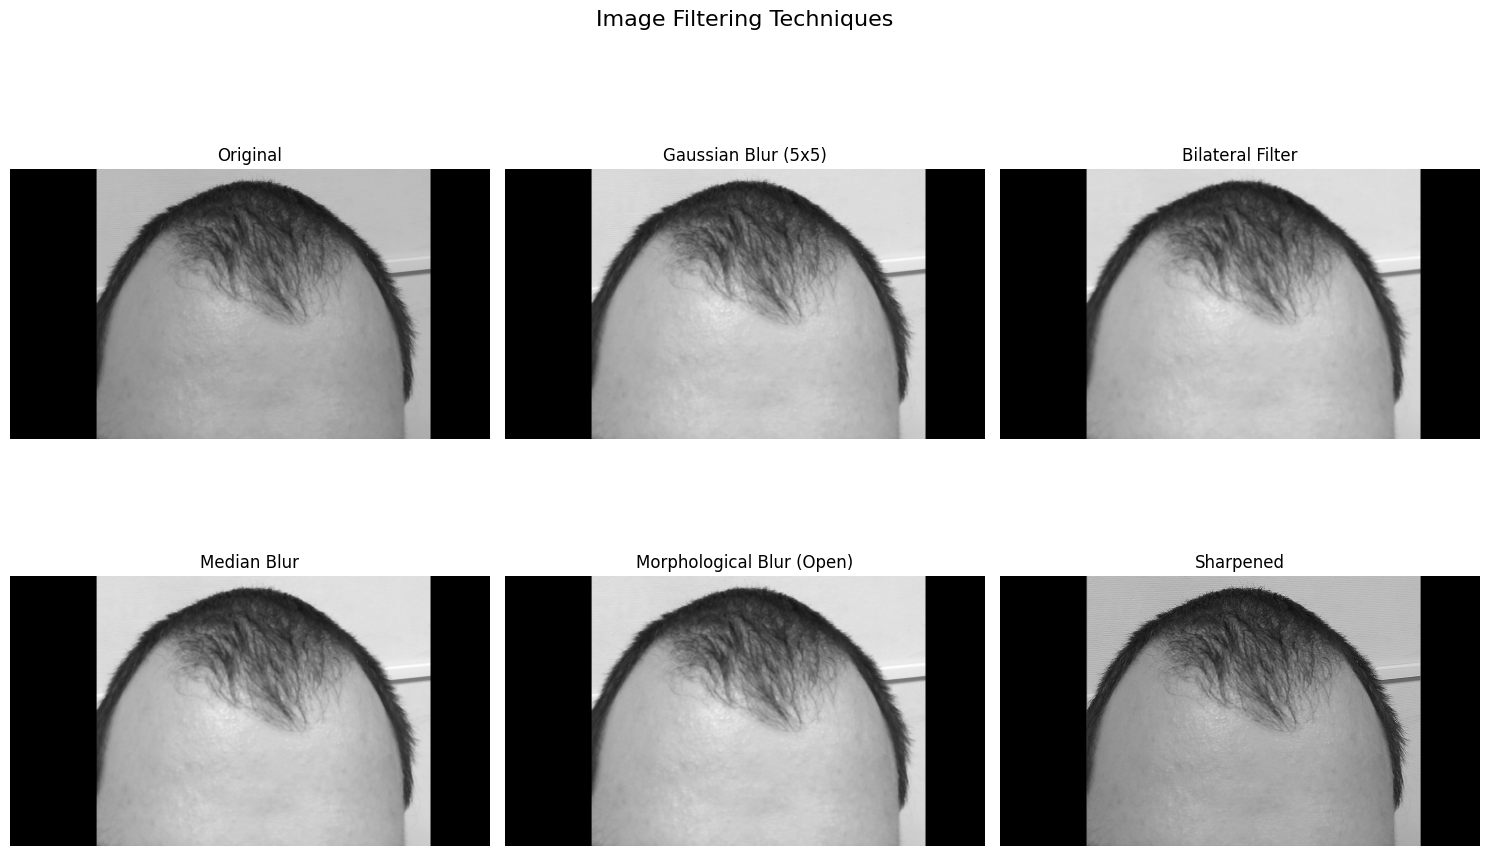

In [6]:
# Different filtering techniques

# 1. Gaussian Blur
gaussian_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)

# 2. Bilateral Filter (edge-preserving)
bilateral = cv2.bilateralFilter(img_gray, 9, 75, 75)

# 3. Median Blur (good for salt-and-pepper noise)
median_blur = cv2.medianBlur(img_gray, 5)

# 4. Morphological Blur
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
morph_blur = cv2.morphologyEx(img_gray, cv2.MORPH_OPEN, kernel)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(gaussian_blur, cmap='gray')
axes[0, 1].set_title('Gaussian Blur (5x5)')
axes[0, 1].axis('off')

axes[0, 2].imshow(bilateral, cmap='gray')
axes[0, 2].set_title('Bilateral Filter')
axes[0, 2].axis('off')

axes[1, 0].imshow(median_blur, cmap='gray')
axes[1, 0].set_title('Median Blur')
axes[1, 0].axis('off')

axes[1, 1].imshow(morph_blur, cmap='gray')
axes[1, 1].set_title('Morphological Blur (Open)')
axes[1, 1].axis('off')

# Sharpening filter
kernel_sharp = np.array([[-1, -1, -1],
                          [-1,  9, -1],
                          [-1, -1, -1]])
sharpened = cv2.filter2D(img_gray, -1, kernel_sharp)
axes[1, 2].imshow(sharpened, cmap='gray')
axes[1, 2].set_title('Sharpened')
axes[1, 2].axis('off')

plt.suptitle('Image Filtering Techniques', fontsize=16)
plt.tight_layout()
plt.show()

## Step 7: Morphological Operations

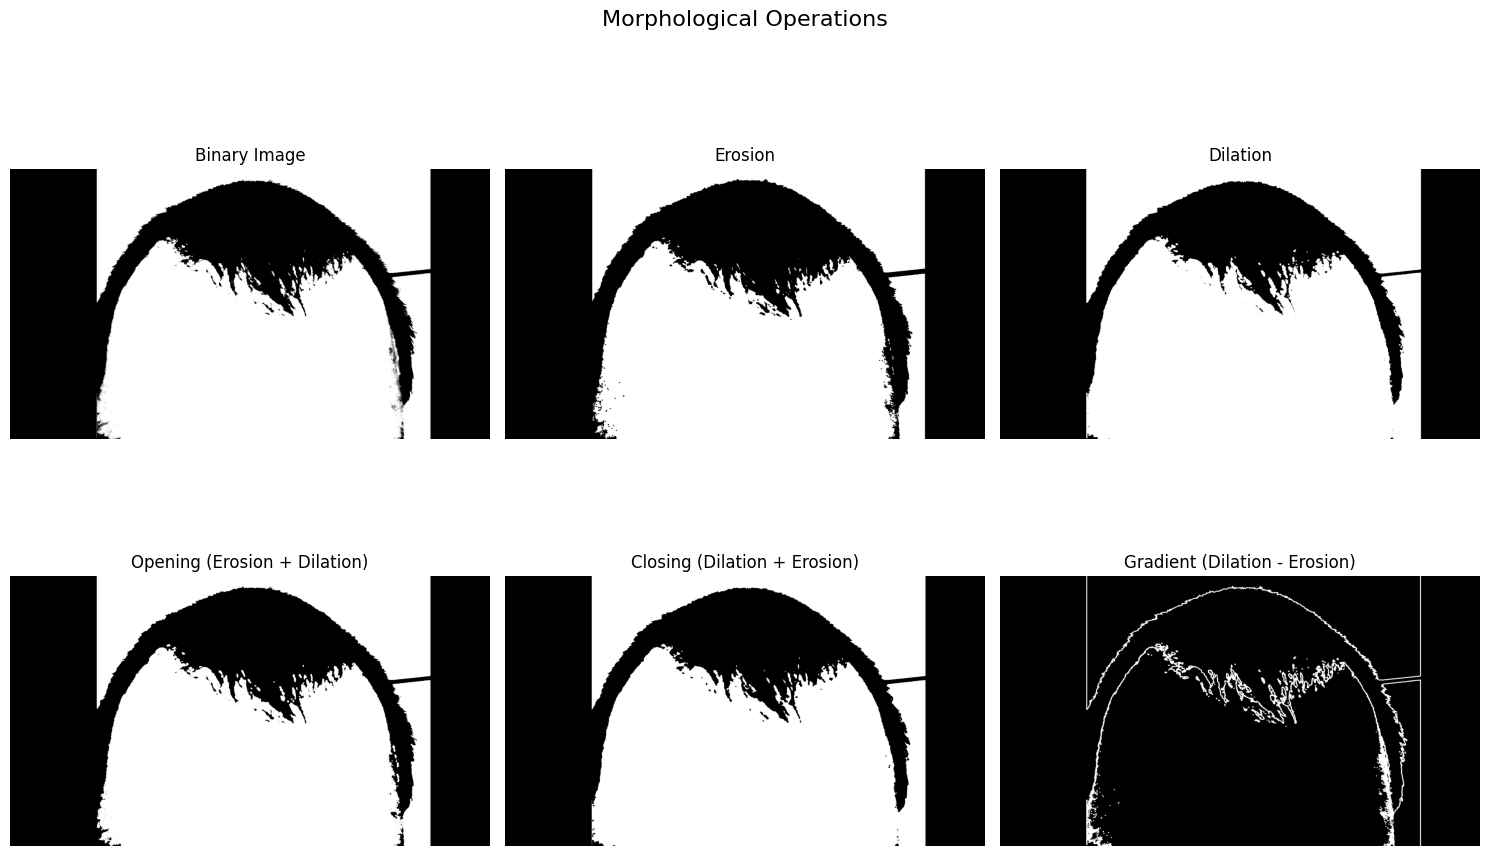

In [7]:
# Convert to binary image for morphological operations
_, binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Define kernel
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Morphological operations
erosion = cv2.erode(binary, kernel, iterations=1)
dilation = cv2.dilate(binary, kernel, iterations=1)
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
tophat = cv2.morphologyEx(binary, cv2.MORPH_TOPHAT, kernel)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(binary, cmap='gray')
axes[0, 0].set_title('Binary Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(erosion, cmap='gray')
axes[0, 1].set_title('Erosion')
axes[0, 1].axis('off')

axes[0, 2].imshow(dilation, cmap='gray')
axes[0, 2].set_title('Dilation')
axes[0, 2].axis('off')

axes[1, 0].imshow(opening, cmap='gray')
axes[1, 0].set_title('Opening (Erosion + Dilation)')
axes[1, 0].axis('off')

axes[1, 1].imshow(closing, cmap='gray')
axes[1, 1].set_title('Closing (Dilation + Erosion)')
axes[1, 1].axis('off')

axes[1, 2].imshow(gradient, cmap='gray')
axes[1, 2].set_title('Gradient (Dilation - Erosion)')
axes[1, 2].axis('off')

plt.suptitle('Morphological Operations', fontsize=16)
plt.tight_layout()
plt.show()

## Step 8: Thresholding Techniques

/var/folders/7z/pkj48l4n56db93wwt59h04br0000gn/T/ipykernel_56305/1008318117.py:40: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 2].hist(img_gray.ravel(), 256, [0, 256], color='black')


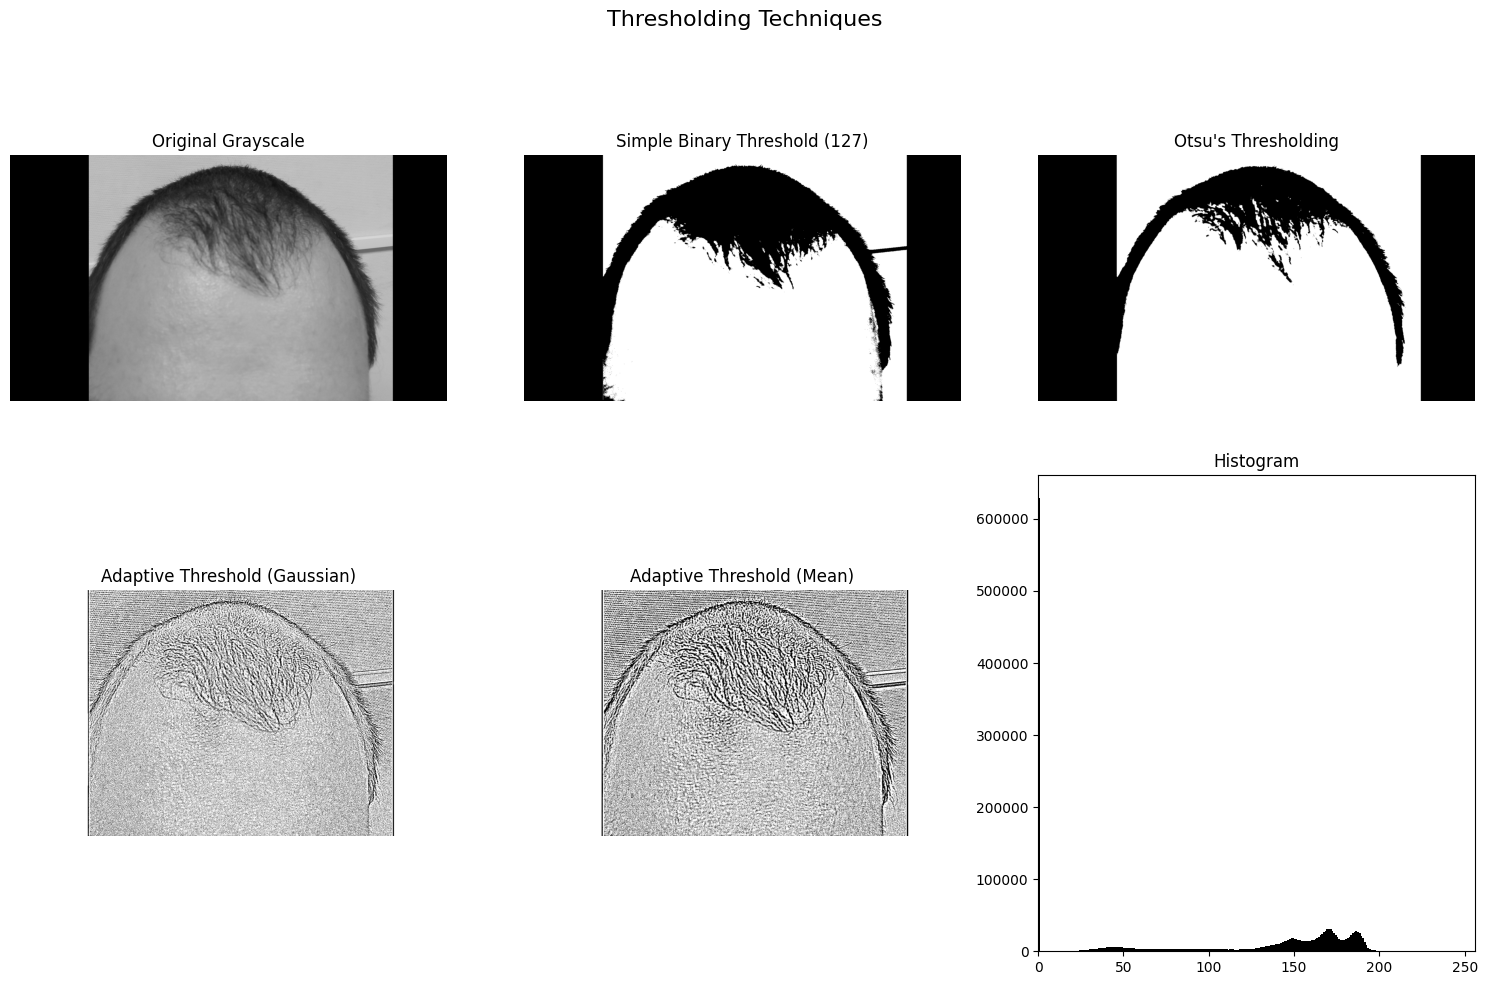

In [8]:
# Different thresholding methods

# 1. Simple Binary Threshold
_, thresh_simple = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# 2. Otsu's Thresholding
_, thresh_otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. Adaptive Thresholding (Gaussian)
thresh_adaptive = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                        cv2.THRESH_BINARY, 11, 2)

# 4. Adaptive Thresholding (Mean)
thresh_adaptive_mean = cv2.adaptiveThreshold(img_gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                             cv2.THRESH_BINARY, 11, 2)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Grayscale')
axes[0, 0].axis('off')

axes[0, 1].imshow(thresh_simple, cmap='gray')
axes[0, 1].set_title('Simple Binary Threshold (127)')
axes[0, 1].axis('off')

axes[0, 2].imshow(thresh_otsu, cmap='gray')
axes[0, 2].set_title('Otsu\'s Thresholding')
axes[0, 2].axis('off')

axes[1, 0].imshow(thresh_adaptive, cmap='gray')
axes[1, 0].set_title('Adaptive Threshold (Gaussian)')
axes[1, 0].axis('off')

axes[1, 1].imshow(thresh_adaptive_mean, cmap='gray')
axes[1, 1].set_title('Adaptive Threshold (Mean)')
axes[1, 1].axis('off')

# Histogram
axes[1, 2].hist(img_gray.ravel(), 256, [0, 256], color='black')
axes[1, 2].set_title('Histogram')
axes[1, 2].set_xlim([0, 256])

plt.suptitle('Thresholding Techniques', fontsize=16)
plt.tight_layout()
plt.show()

## Step 9: Histogram Equalization

/var/folders/7z/pkj48l4n56db93wwt59h04br0000gn/T/ipykernel_56305/4020716164.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='blue', label='Original')
/var/folders/7z/pkj48l4n56db93wwt59h04br0000gn/T/ipykernel_56305/4020716164.py:34: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 1].hist(equalized.ravel(), 256, [0, 256], color='green', label='Equalized')
/var/folders/7z/pkj48l4n56db93wwt59h04br0000gn/T/ipykernel_56305/4020716164.py:39: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1, 2].hist(clahe_result.ravel(), 256, [0, 256], color='red', label='CLAHE')


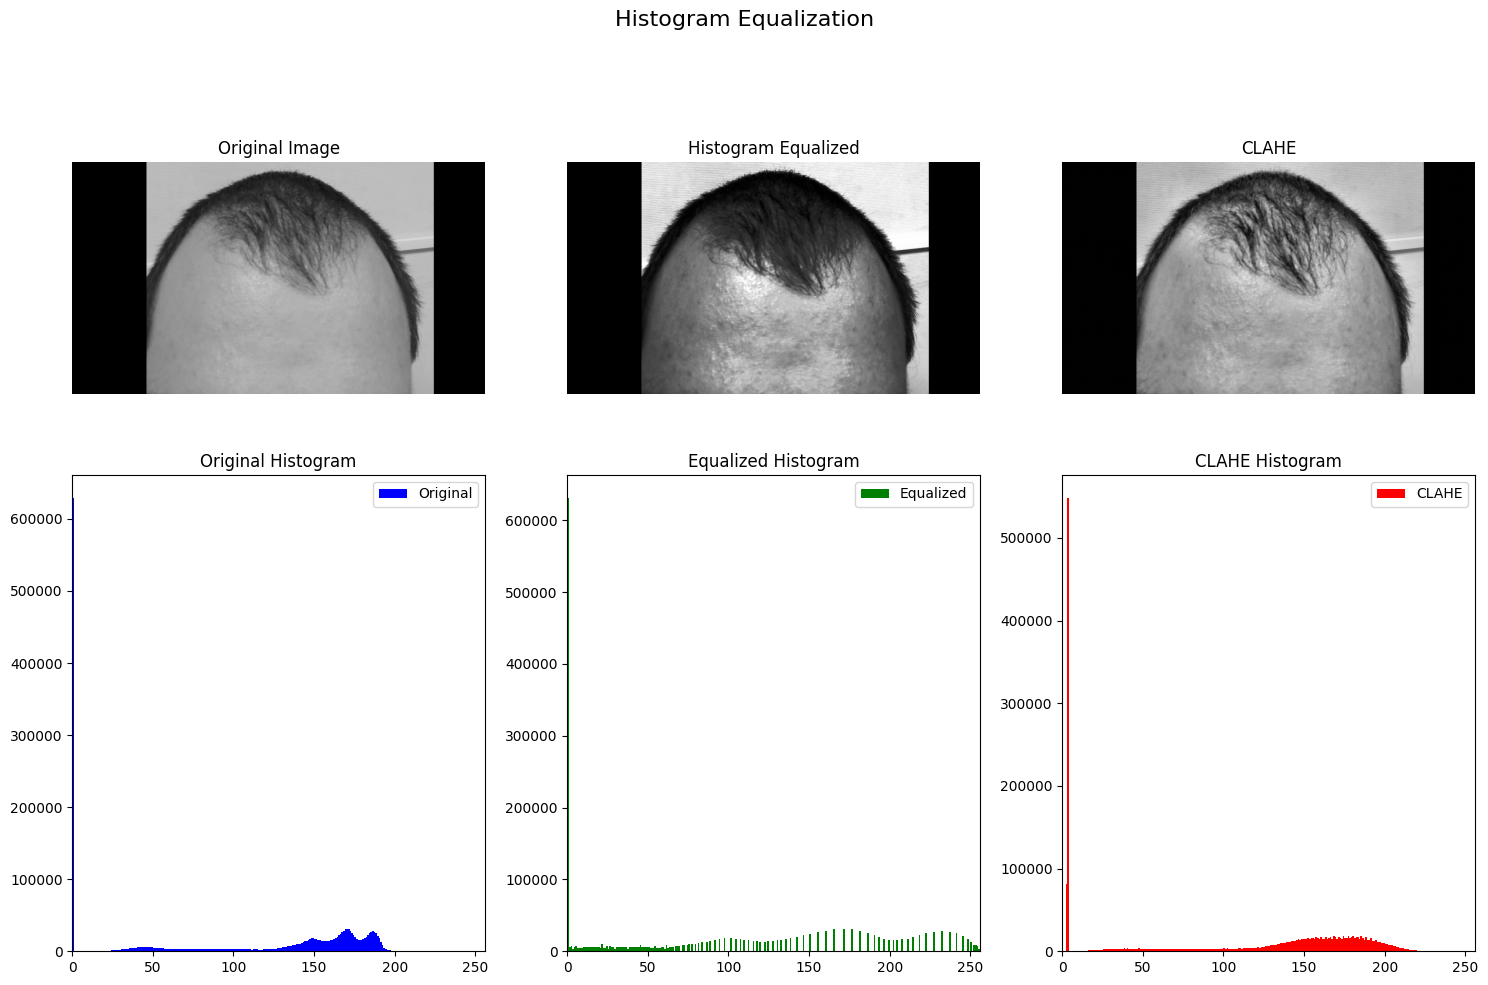

In [9]:
# Histogram equalization

# 1. Standard Histogram Equalization
equalized = cv2.equalizeHist(img_gray)

# 2. CLAHE (Contrast Limited Adaptive Histogram Equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
clahe_result = clahe.apply(img_gray)

# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Original
axes[0, 0].imshow(img_gray, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Equalized
axes[0, 1].imshow(equalized, cmap='gray')
axes[0, 1].set_title('Histogram Equalized')
axes[0, 1].axis('off')

# CLAHE
axes[0, 2].imshow(clahe_result, cmap='gray')
axes[0, 2].set_title('CLAHE')
axes[0, 2].axis('off')

# Histograms
axes[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='blue', label='Original')
axes[1, 0].set_title('Original Histogram')
axes[1, 0].set_xlim([0, 256])
axes[1, 0].legend()

axes[1, 1].hist(equalized.ravel(), 256, [0, 256], color='green', label='Equalized')
axes[1, 1].set_title('Equalized Histogram')
axes[1, 1].set_xlim([0, 256])
axes[1, 1].legend()

axes[1, 2].hist(clahe_result.ravel(), 256, [0, 256], color='red', label='CLAHE')
axes[1, 2].set_title('CLAHE Histogram')
axes[1, 2].set_xlim([0, 256])
axes[1, 2].legend()

plt.suptitle('Histogram Equalization', fontsize=16)
plt.tight_layout()
plt.show()

## Step 10: Contour Detection and Analysis

Number of contours found: 1832

Top 5 largest contours by area:
  1. Contour 332: Area=821166.50, Perimeter=10679.90, Vertices=6
  2. Contour 1801: Area=274504.50, Perimeter=5108.29, Vertices=6
  3. Contour 530: Area=762.00, Perimeter=416.42, Vertices=5
  4. Contour 158: Area=579.50, Perimeter=221.52, Vertices=8
  5. Contour 1445: Area=485.00, Perimeter=183.14, Vertices=7


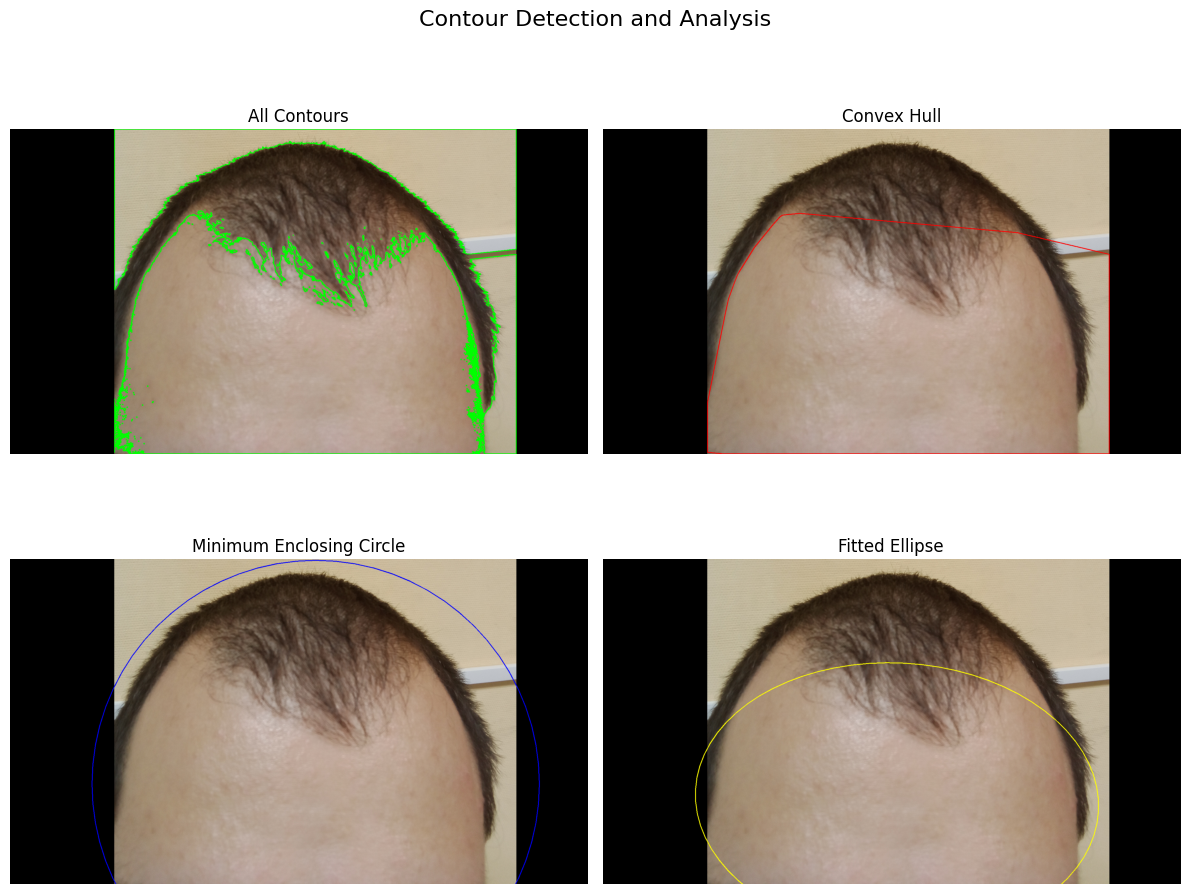

In [10]:
# Contour detection
_, binary_for_contours = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

# Find contours
contours, hierarchy = cv2.findContours(binary_for_contours, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on original image
contour_image = img_rgb.copy()
cv2.drawContours(contour_image, contours, -1, (0, 255, 0), 2)

# Get contour properties
print(f"Number of contours found: {len(contours)}")
print("\nTop 5 largest contours by area:")

contour_areas = [(i, cv2.contourArea(c)) for i, c in enumerate(contours)]
contour_areas.sort(key=lambda x: x[1], reverse=True)

for idx, (i, area) in enumerate(contour_areas[:5]):
    c = contours[i]
    perimeter = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * perimeter, True)
    print(f"  {idx+1}. Contour {i}: Area={area:.2f}, Perimeter={perimeter:.2f}, Vertices={len(approx)}")

# Convex hull
if len(contours) > 0:
    largest_contour = contours[contour_areas[0][0]]
    hull = cv2.convexHull(largest_contour)
    
    # Draw convex hull
    hull_image = img_rgb.copy()
    cv2.drawContours(hull_image, [hull], 0, (255, 0, 0), 2)
    
    # Fit circle and ellipse
    (x, y), radius = cv2.minEnclosingCircle(largest_contour)
    circle_image = img_rgb.copy()
    cv2.circle(circle_image, (int(x), int(y)), int(radius), (0, 0, 255), 2)
    
    if len(largest_contour) >= 5:
        ellipse = cv2.fitEllipse(largest_contour)
        ellipse_image = img_rgb.copy()
        cv2.ellipse(ellipse_image, ellipse, (255, 255, 0), 2)
    
    # Display results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes[0, 0].imshow(contour_image)
    axes[0, 0].set_title('All Contours')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(hull_image)
    axes[0, 1].set_title('Convex Hull')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(circle_image)
    axes[1, 0].set_title('Minimum Enclosing Circle')
    axes[1, 0].axis('off')
    
    if len(largest_contour) >= 5:
        axes[1, 1].imshow(ellipse_image)
        axes[1, 1].set_title('Fitted Ellipse')
    else:
        axes[1, 1].imshow(img_rgb)
        axes[1, 1].set_title('(Ellipse requires >=5 points)')
    axes[1, 1].axis('off')
    
    plt.suptitle('Contour Detection and Analysis', fontsize=16)
    plt.tight_layout()
    plt.show()

## Step 11: Process All Images

Processing 6 images...



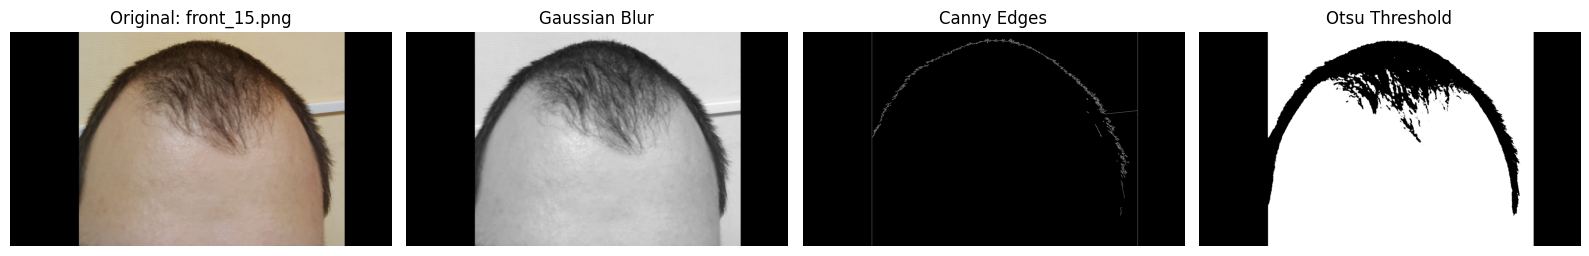

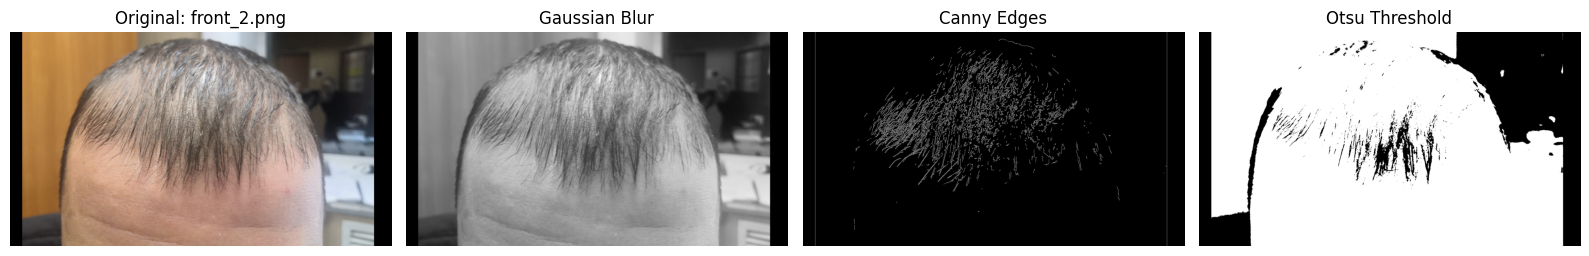

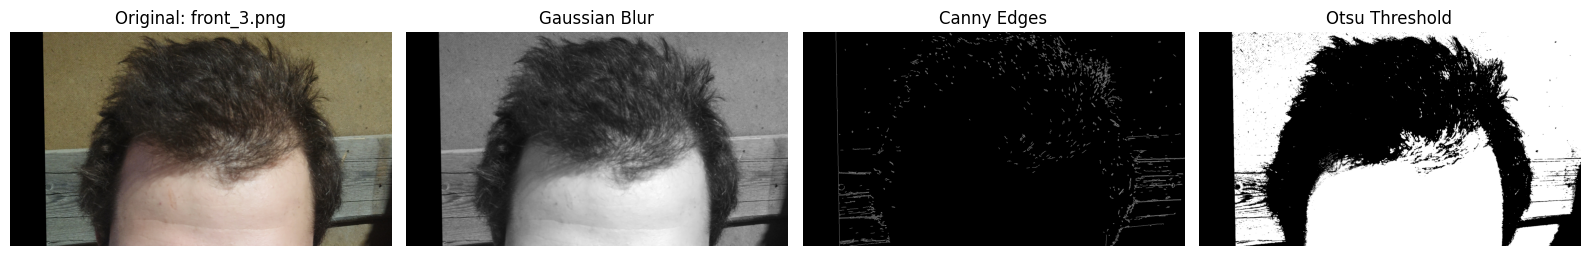

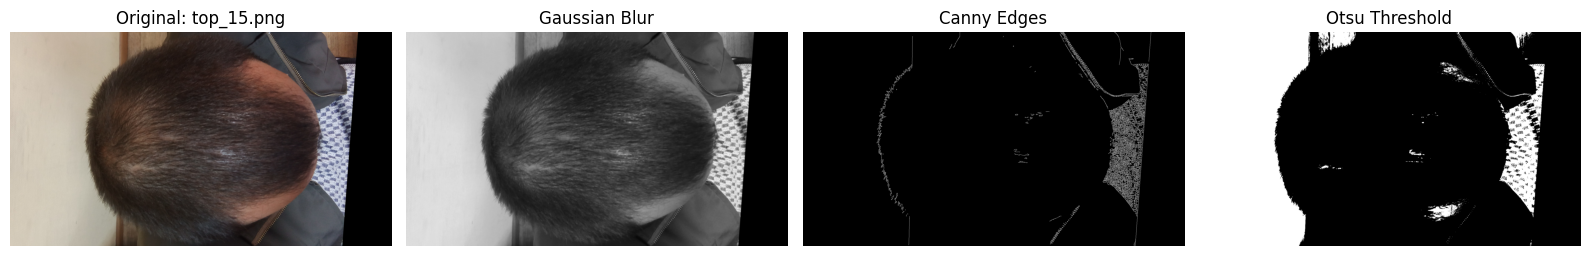

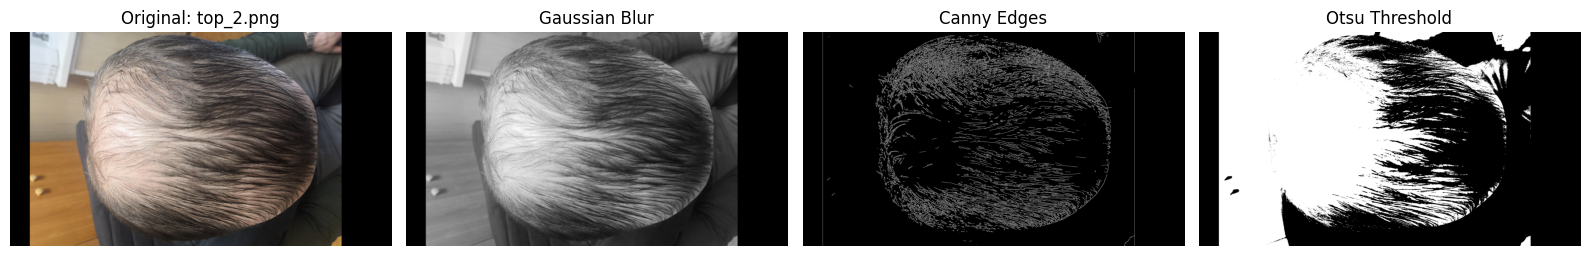

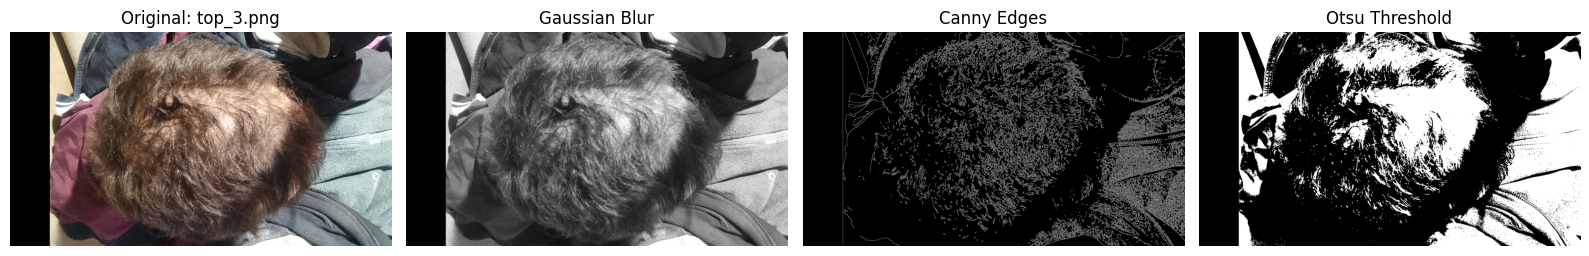

In [11]:
# Process all PNG images and create comparison
print(f"Processing {len(image_files)} images...\n")

for img_file in image_files:
    img = cv2.imread(str(img_file))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Apply different techniques
    canny = cv2.Canny(img_gray, 100, 200)
    gaussian_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    _, otsu = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Display
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(img_rgb)
    axes[0].set_title(f'Original: {img_file.name}')
    axes[0].axis('off')
    
    axes[1].imshow(gaussian_blur, cmap='gray')
    axes[1].set_title('Gaussian Blur')
    axes[1].axis('off')
    
    axes[2].imshow(canny, cmap='gray')
    axes[2].set_title('Canny Edges')
    axes[2].axis('off')
    
    axes[3].imshow(otsu, cmap='gray')
    axes[3].set_title('Otsu Threshold')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

## Step 12: Summary and Key Techniques

### Techniques Applied:

1. **Geometric Transformations**: Rotation, scaling, translation, and flipping
2. **Edge Detection**: Canny, Sobel, and Laplacian methods
3. **Filtering**: Gaussian blur, bilateral filter, median blur, and sharpening
4. **Morphological Operations**: Erosion, dilation, opening, closing, gradient, and tophat
5. **Thresholding**: Binary, Otsu, and adaptive thresholding
6. **Histogram Equalization**: Standard and CLAHE methods
7. **Contour Detection**: Finding and analyzing image contours

### When to Use Each:
- **Canny**: Best for general edge detection
- **Otsu**: Best for automatic threshold selection
- **Gaussian Blur**: General purpose smoothing
- **Morphological Ops**: Cleaning binary images
- **Adaptive Threshold**: Varying lighting conditions
- **CLAHE**: Enhancing contrast while preserving edges

## Step 13: Image Metrics

This section computes simple quantitative metrics for each image:

- **Mean intensity** and **standard deviation** (overall brightness/contrast)
- **Edge density** from Canny edges
- **Foreground ratio** from Otsu thresholding
- **Largest contour area ratio** and **circularity** (shape quality)
- **Pixel accuracy** *(only if a ground-truth mask is available)*

These metrics help compare results beyond visual inspection.

image                mean      std     edge       fg     area     circ      acc
-------------------------------------------------------------------------------
front_15.png        99.94    76.01    0.004    0.584    0.580    0.084      N/A
front_2.png        126.44    57.47    0.026    0.763    0.784    0.242      N/A
front_3.png         89.65    58.45    0.012    0.533    0.276    0.034      N/A
top_15.png          88.04    68.81    0.017    0.289    0.240    0.296      N/A
top_2.png           91.39    69.30    0.059    0.464    0.415    0.012      N/A
top_3.png           94.90    66.24    0.100    0.367    0.130    0.012      N/A

Accuracy is N/A for all images because no matching ground-truth masks were found.
Add masks as <name>_mask.png, <name>_gt.png, or masks/<name>.png to enable accuracy.


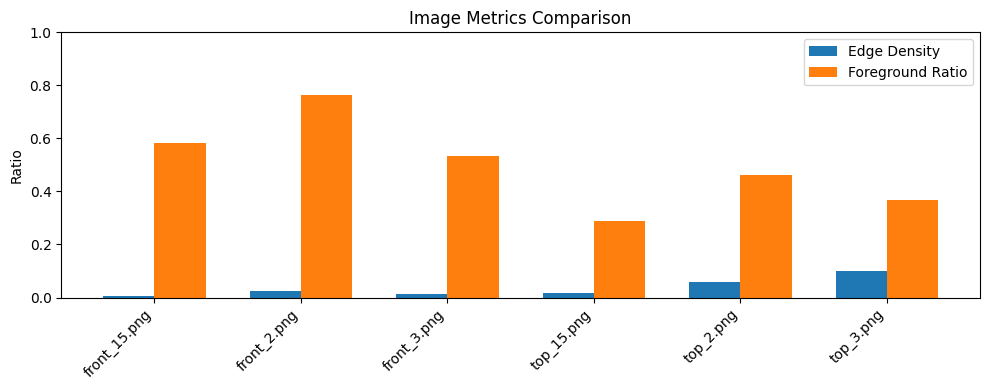

In [14]:
# Compute metrics for all PNG images
metrics_rows = []

for img_file in image_files:
    img = cv2.imread(str(img_file))
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Basic intensity metrics
    mean_intensity = float(np.mean(img_gray))
    std_intensity = float(np.std(img_gray))

    # Edge density (fraction of edge pixels)
    edges = cv2.Canny(img_gray, 100, 200)
    edge_density = float(np.mean(edges > 0))

    # Foreground ratio from Otsu threshold
    _, otsu_mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    foreground_ratio = float(np.mean(otsu_mask > 0))

    # Largest contour metrics (on Otsu mask)
    contours, _ = cv2.findContours(otsu_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = float(cv2.contourArea(largest))
        perimeter = float(cv2.arcLength(largest, True))
        area_ratio = area / float(img_gray.shape[0] * img_gray.shape[1])
        circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else 0.0
    else:
        area_ratio = 0.0
        circularity = 0.0

    # Optional pixel accuracy (requires ground-truth mask)
    # Supported mask names: <stem>_mask.png, <stem>_gt.png, masks/<stem>.png
    pred = (otsu_mask > 0).astype(np.uint8)
    mask_candidates = [
        img_file.parent / f"{img_file.stem}_mask.png",
        img_file.parent / f"{img_file.stem}_gt.png",
        img_file.parent / "masks" / f"{img_file.stem}.png",
    ]
    gt = None
    for mpath in mask_candidates:
        if mpath.exists():
            gt_img = cv2.imread(str(mpath), cv2.IMREAD_GRAYSCALE)
            if gt_img is not None:
                if gt_img.shape != pred.shape:
                    gt_img = cv2.resize(gt_img, (pred.shape[1], pred.shape[0]), interpolation=cv2.INTER_NEAREST)
                gt = (gt_img > 127).astype(np.uint8)
                break

    accuracy = float(np.mean(pred == gt)) if gt is not None else np.nan

    metrics_rows.append({
        'image': img_file.name,
        'mean_intensity': mean_intensity,
        'std_intensity': std_intensity,
        'edge_density': edge_density,
        'foreground_ratio': foreground_ratio,
        'largest_area_ratio': area_ratio,
        'circularity': circularity,
        'accuracy': accuracy,
    })

# Print compact table
header = f"{'image':<16} {'mean':>8} {'std':>8} {'edge':>8} {'fg':>8} {'area':>8} {'circ':>8} {'acc':>8}"
print(header)
print('-' * len(header))
for r in metrics_rows:
    acc_text = f"{r['accuracy']:.3f}" if np.isfinite(r['accuracy']) else "N/A"
    print(
        f"{r['image']:<16} "
        f"{r['mean_intensity']:>8.2f} "
        f"{r['std_intensity']:>8.2f} "
        f"{r['edge_density']:>8.3f} "
        f"{r['foreground_ratio']:>8.3f} "
        f"{r['largest_area_ratio']:>8.3f} "
        f"{r['circularity']:>8.3f} "
        f"{acc_text:>8}"
    )

if not any(np.isfinite(r['accuracy']) for r in metrics_rows):
    print("\nAccuracy is N/A for all images because no matching ground-truth masks were found.")
    print("Add masks as <name>_mask.png, <name>_gt.png, or masks/<name>.png to enable accuracy.")

# Optional visual comparison for edge and foreground ratios
names = [r['image'] for r in metrics_rows]
edge_vals = [r['edge_density'] for r in metrics_rows]
fg_vals = [r['foreground_ratio'] for r in metrics_rows]

x = np.arange(len(names))
w = 0.35
plt.figure(figsize=(10, 4))
plt.bar(x - w/2, edge_vals, width=w, label='Edge Density')
plt.bar(x + w/2, fg_vals, width=w, label='Foreground Ratio')
plt.xticks(x, names, rotation=45, ha='right')
plt.ylim(0, 1)
plt.ylabel('Ratio')
plt.title('Image Metrics Comparison')
plt.legend()
plt.tight_layout()
plt.show()